# Lab 1 — Visualization Analysis & Design: Foundations

**Data Visualization Course** | Master's Program | USFQ  
**Week 1** | Instructor: Carla Parra, Ph.D. candidate

---

## Overview

This lab covers the foundational concepts of data visualization introduced in Week 1:

1. **What is visualization and why does it matter?** — the role of external representations, perception vs. cognition, and the value of showing all the data.
2. **Misleading visualizations** — common techniques that distort or deceive, and how to spot them.
3. **Data abstraction** — dataset types (tables, networks, fields, geometry) and attribute types (categorical, ordinal, quantitative).
4. **Task abstraction** — the action/target vocabulary for describing what users do with visualizations.
5. **Marks and channels** — the grammar of visual encoding: geometric primitives and how their appearance encodes data.
6. **Arranging tables** — choosing and constructing the right chart idiom for tabular data.

---

## Grading

Each activity is worth the same number of points.

---

# Part 1: Guided Walkthrough

In this section we work through the core ideas step by step, combining theory with code. Each concept is illustrated with a concrete example so you can see both *what* it means and *how* it translates into Python.

---

## 1. Why Visualization? Perception Over Cognition

A classic result in visualization research is **Anscombe's Quartet** (1973): four datasets that share nearly identical summary statistics — same mean, variance, and correlation — yet look completely different when plotted. This example motivates the core argument of the field:

> *Summaries lose information. Details matter. Visual representations let humans use their high-bandwidth perceptual system to find patterns, outliers, and structure that numbers alone hide.*

The lesson: **always visualize your data before summarizing it**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Anscombe's Quartet — four datasets with identical summary statistics
anscombe = {
    "I":   {"x": [10,8,13,9,11,14,6,4,12,7,5],
            "y": [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68]},
    "II":  {"x": [10,8,13,9,11,14,6,4,12,7,5],
            "y": [9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]},
    "III": {"x": [10,8,13,9,11,14,6,4,12,7,5],
            "y": [7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]},
    "IV":  {"x": [8,8,8,8,8,8,8,19,8,8,8],
            "y": [6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89]},
}

# Print summary statistics to show they are nearly identical
print("Summary statistics for Anscombe's Quartet:\n")
print(f"{'Dataset':<10} {'x mean':>10} {'x var':>10} {'y mean':>10} {'y var':>10} {'corr':>10}")
print("-" * 55)
for name, data in anscombe.items():
    x, y = np.array(data["x"]), np.array(data["y"])
    corr = np.corrcoef(x, y)[0, 1]
    print(f"{name:<10} {x.mean():>10.2f} {x.var():>10.2f} {y.mean():>10.2f} {y.var():>10.2f} {corr:>10.3f}")

Summary statistics for Anscombe's Quartet:

Dataset        x mean      x var     y mean      y var       corr
-------------------------------------------------------
I                9.00      10.00       7.50       3.75      0.816
II               9.00      10.00       7.50       3.75      0.816
III              9.00      10.00       7.50       3.75      0.816
IV               9.00      10.00       7.50       3.75      0.817


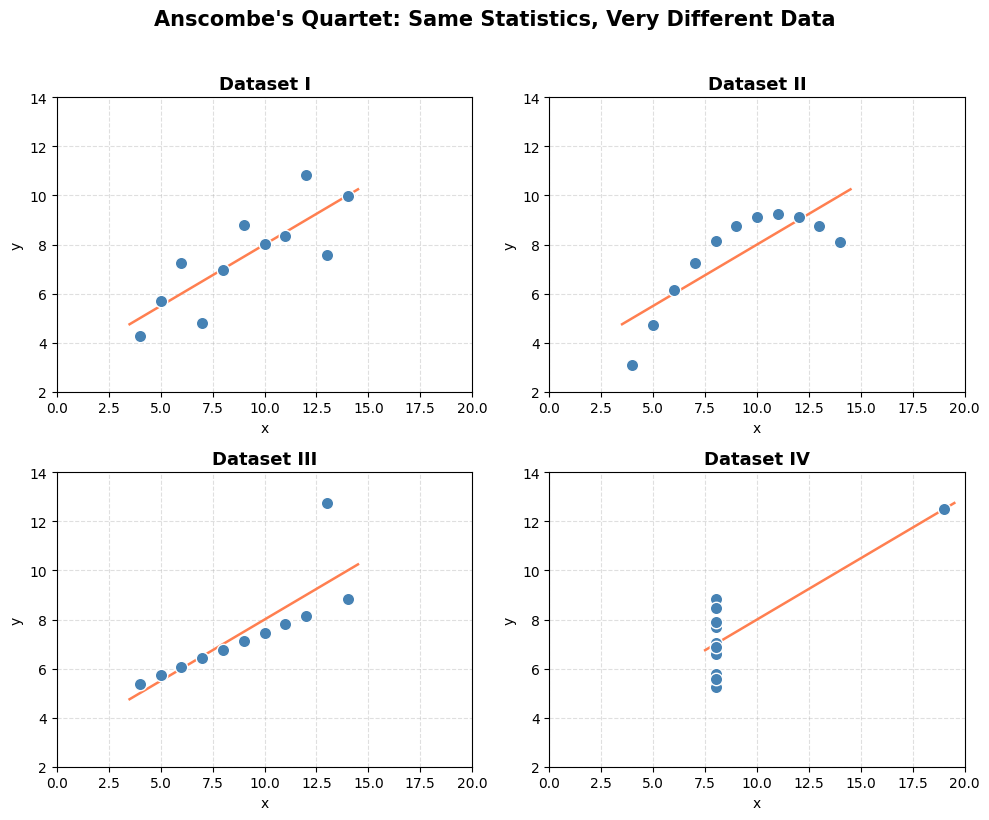

In [2]:
# Now plot all four datasets — identical statistics, wildly different shapes
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (name, data) in zip(axes, anscombe.items()):
    x, y = np.array(data["x"]), np.array(data["y"])

    # Scatter plot for each dataset
    ax.scatter(x, y, color="steelblue", edgecolors="white", s=80, zorder=3)

    # Fit and draw the regression line (same slope/intercept for all four)
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min() - 0.5, x.max() + 0.5, 100)
    ax.plot(x_line, m * x_line + b, color="coral", linewidth=1.8, zorder=2)

    ax.set_title(f"Dataset {name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(0, 20)
    ax.set_ylim(2, 14)
    ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Anscombe's Quartet: Same Statistics, Very Different Data",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Key takeaway: perception reveals what numbers hide

## 💡 Interpretation
### Dataset I — Linear with scatter

Dataset I is the "well-behaved" case. The points are scattered around a straight line with no systematic pattern in the residuals. A linear regression model is genuinely appropriate here: the relationship between x and y is linear, and the variance looks roughly constant across the range of x. If you only looked at the summary statistics, you might assume all four datasets look like this — they do not.

### Dataset II — Curved (non-linear) relationship

Dataset II reveals a smooth, curved arc — a clearly non-linear relationship. A straight regression line fits poorly: it overshoots in the middle and undershoots at both ends. The correct model here would be a polynomial (e.g., quadratic) regression, not a linear one. Yet the correlation coefficient is 0.816 — identical to Dataset I — because correlation measures the *strength* of a linear association, not whether the relationship is actually linear. This is a direct warning: a high r does not validate a linear model.

### Dataset III — Linear with one outlier

Dataset III would be a near-perfect linear relationship — except for a single influential outlier at x ≈ 13, y ≈ 12.7. That one point pulls the regression line upward and inflates both the slope and the correlation. Without the outlier, the remaining points lie almost exactly on a line with a lower slope. This illustrates how **a single extreme observation can dominate a fitted model**, and why outlier detection must precede regression analysis. A residual plot or a simple scatter would catch this immediately; the summary statistics give no indication.

### Dataset IV — Vertical cluster with a single leverage point

Dataset IV is the most extreme case. Almost all x values are identical (x = 8), so the points form a vertical cluster with no horizontal spread. A regression line cannot be determined from a vertical cluster alone — there is no linear relationship to fit. The slope is entirely driven by a single high-leverage point at x = 19, y = 12.5. Remove that one point and the regression line becomes undefined. This is a degenerate structure: the data does not satisfy the basic assumption of variation in the predictor, yet the summary statistics — including a correlation of 0.817 — look perfectly normal.

## 2. Misleading Visualizations

Not every visualization is honest. The slides covered several common ways charts mislead:

| Technique | What goes wrong |
|---|---|
| **Truncated y-axis** | Starting the axis at a non-zero value exaggerates small differences |
| **3D / perspective effects** | Depth distorts area perception — front slices look larger |
| **Scaled pictograms** | Scaling both width and height makes area grow quadratically (4×) even when data only doubled |
| **Cherry-picking data** | Showing only a subset that supports a chosen narrative |
| **Wrong chart type** | Using a line chart for categorical data implies a trend that doesn't exist |

The following code recreates the **truncated y-axis** problem and its honest fix. This is one of the most common misleading patterns you will encounter in the wild.

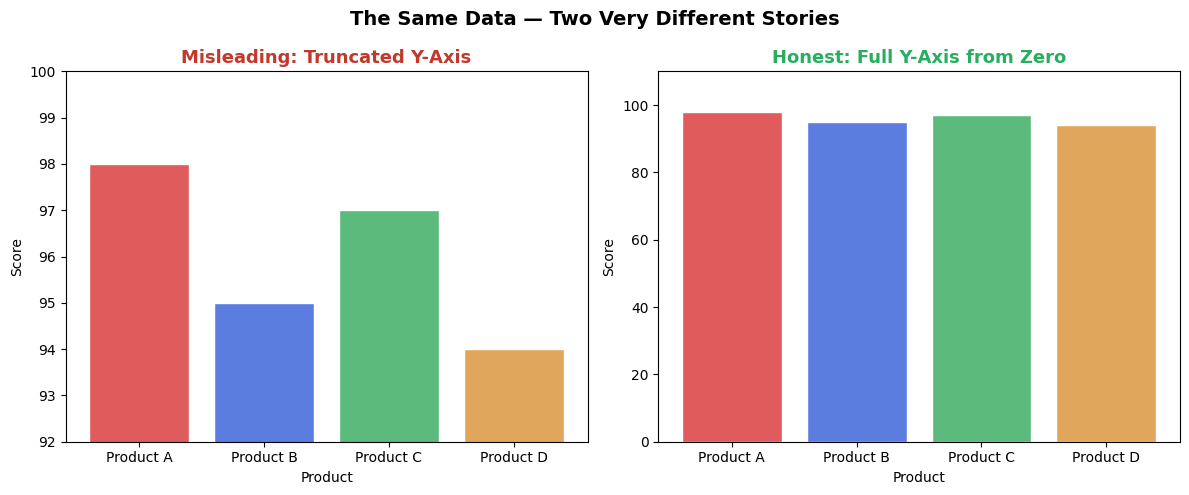

All four products score between 94 and 98 — barely any difference.
The truncated axis makes Product A look ~5x better than Product D.


In [3]:
# Truncated vs. honest y-axis — a side-by-side comparison
categories = ["Product A", "Product B", "Product C", "Product D"]
values = [98, 95, 97, 94]   # very similar values, all close to 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- MISLEADING: y-axis starts at 92, making tiny differences look dramatic ---
ax1.bar(categories, values, color=["#e05c5c", "#5c7de0", "#5cba7d", "#e0a75c"], edgecolor="white")
ax1.set_ylim(92, 100)   # truncated — differences appear huge
ax1.set_title("Misleading: Truncated Y-Axis", fontsize=13, fontweight="bold", color="#c0392b")
ax1.set_ylabel("Score")
ax1.set_xlabel("Product")
# No label on y-axis minimum makes it easy to miss the truncation

# --- HONEST: y-axis includes 0, showing the true scale ---
ax2.bar(categories, values, color=["#e05c5c", "#5c7de0", "#5cba7d", "#e0a75c"], edgecolor="white")
ax2.set_ylim(0, 110)    # full scale — the differences are actually tiny
ax2.set_title("Honest: Full Y-Axis from Zero", fontsize=13, fontweight="bold", color="#27ae60")
ax2.set_ylabel("Score")
ax2.set_xlabel("Product")

plt.suptitle("The Same Data — Two Very Different Stories", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("All four products score between 94 and 98 — barely any difference.")
print("The truncated axis makes Product A look ~5x better than Product D.")

## 💡 Interpretation:
#### Left — Misleading (truncated Y-axis, starts at 92)

Product A looks more than twice as tall as Product D
The differences look dramatic
The reader concludes: "some products are far superior to others"

#### Right — Honest (Y-axis from 0)

All bars look nearly the same height
The real differences are minimal (94 vs 98 out of 100)
The reader concludes: "all products perform similarly"

## 3. Data Abstraction: Understanding What You Have

Before choosing a visualization, you need to answer: **What kind of data is this?**

Munzner's framework distinguishes between **dataset types** and **attribute types**:

### Dataset Types

| Type | Description | Example |
|---|---|---|
| **Table** | Items (rows) × attributes (columns) | Student grades spreadsheet |
| **Network / Tree** | Items connected by links | Social network, org chart |
| **Field (Continuous)** | Values associated with cells over a grid | Temperature map, MRI scan |
| **Geometry** | Explicit spatial positions/shapes | Geographic maps, CAD models |

### Attribute Types

| Type | Meaning | Operations | Example |
|---|---|---|---|
| **Categorical** | Membership — belongs to a group or not | equality only | Country, species, genre |
| **Ordinal** | Has a natural order, but intervals not meaningful | less/greater than | Education level, satisfaction rating |
| **Quantitative** | Numeric with meaningful magnitude | arithmetic | Temperature in °C, salary, age |

Getting attribute types right directly determines which visual channel is appropriate (see Section 5 below). Encoding a categorical attribute with a magnitude channel (like length) is a category error — it implies differences that don't exist in the data.

In [4]:
import pandas as pd

# A small dataset that mixes all three attribute types
# This represents a sample of students in a course
data = {
    "student_id": [1, 2, 3, 4, 5, 6, 7, 8],
    "major":      ["CS", "Biology", "CS", "Physics", "Biology", "CS", "Physics", "Biology"],  # categorical
    "grade":      ["A", "B+", "A-", "B", "A", "C+", "B+", "A-"],                              # ordinal
    "score":      [92.5, 84.0, 88.5, 79.0, 95.0, 71.5, 85.0, 89.5],                          # quantitative
    "hours_studied": [15, 10, 12, 8, 18, 6, 11, 13],                                          # quantitative
}

df = pd.DataFrame(data)

print("Dataset preview:")
print(df.to_string(index=False))
print()

# Classify each column explicitly so the reasoning is transparent
print("Attribute type classification:")
print(f"  student_id    → item key (unique identifier, not a data attribute)")
print(f"  major         → CATEGORICAL  (groups: CS / Biology / Physics — no order)")
print(f"  grade         → ORDINAL      (A > B+ > B … — order meaningful, intervals are not)")
print(f"  score         → QUANTITATIVE (ratio scale — arithmetic makes sense: 92.5 - 79.0 = 13.5 pts)")
print(f"  hours_studied → QUANTITATIVE (ratio scale — 15 hrs is twice 7.5 hrs)")

Dataset preview:
 student_id   major grade  score  hours_studied
          1      CS     A   92.5             15
          2 Biology    B+   84.0             10
          3      CS    A-   88.5             12
          4 Physics     B   79.0              8
          5 Biology     A   95.0             18
          6      CS    C+   71.5              6
          7 Physics    B+   85.0             11
          8 Biology    A-   89.5             13

Attribute type classification:
  student_id    → item key (unique identifier, not a data attribute)
  major         → CATEGORICAL  (groups: CS / Biology / Physics — no order)
  grade         → ORDINAL      (A > B+ > B … — order meaningful, intervals are not)
  score         → QUANTITATIVE (ratio scale — arithmetic makes sense: 92.5 - 79.0 = 13.5 pts)
  hours_studied → QUANTITATIVE (ratio scale — 15 hrs is twice 7.5 hrs)


## 4. Task Abstraction: What Are Users Trying to Do?

Once you know *what* the data is, you need to understand *why* someone is looking at it. Munzner's task abstraction framework uses **{action, target} pairs**:

### Actions

| Level | Options | Example |
|---|---|---|
| **Analyze** | Discover (explore) vs. Present (explain) | Exploring a new dataset vs. making a report slide |
| **Search** | Lookup (known target, known location) / Browse / Locate / Explore | "Find Q3 revenue" vs. "What's interesting here?" |
| **Query** | Identify (one item) / Compare (some) / Summarize (all) | "What is country X's value?" vs. "How do all regions compare?" |

### Targets

What you act on: **trends**, **outliers**, **distribution**, **correlation**, **topology**, **shape**, etc.

### Why this matters

Knowing the task tells you which chart idiom to use. For example:
- Task: *compare values across categories* → bar chart
- Task: *find correlation between two quantitative variables* → scatterplot
- Task: *show part-to-whole composition* → stacked bar or pie chart
- Task: *discover clusters and outliers in a matrix* → heatmap

The next section shows how marks and channels are the building blocks for all of these idioms.

## 5. Marks and Channels: The Grammar of Visual Encoding

Every visualization is built from two ingredients:

- **Marks** — geometric primitives that represent items or links:
  - **Points** (0D) — individual items
  - **Lines** (1D) — relationships, trends, connections
  - **Areas** (2D) — regions, aggregates

- **Channels** — visual properties that encode data values by changing how marks look:

| Channel | Best for | Accuracy rank |
|---|---|---|
| Position (horizontal / vertical) | Quantitative and ordinal | ★★★★★ Highest |
| Length | Quantitative | ★★★★ |
| Color hue | Categorical | ★★★★ |
| Color luminance / saturation | Ordinal / quantitative | ★★★ |
| Size (area) | Quantitative | ★★★ |
| Shape | Categorical | ★★ |
| Tilt / angle | Quantitative | ★★ Lowest |

**Two key principles:**
1. **Expressiveness**: match the channel *type* to the data type — use magnitude channels for quantitative data, identity channels for categorical data.
2. **Effectiveness**: among valid channels, prefer the ones humans can read most accurately (position beats area beats angle).

The code below demonstrates these principles by encoding the same quantitative attribute through different channels and letting you compare how easily you can read the values.

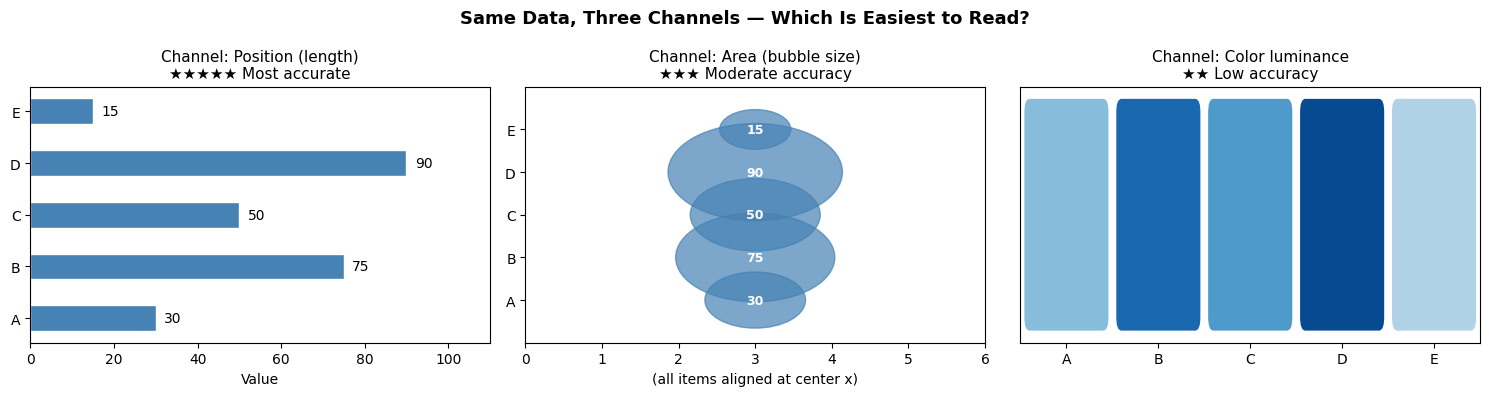

In [5]:
import matplotlib.patches as mpatches
import matplotlib.cm as cm

# Five items with quantitative values we want to compare
items  = ["A", "B", "C", "D", "E"]
values = [30,  75,  50,  90,  15]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Encoding 1: POSITION (bar chart) — most accurate ---
axes[0].barh(items, values, color="steelblue", edgecolor="white", height=0.5)
axes[0].set_xlim(0, 110)
axes[0].set_title("Channel: Position (length)\n★★★★★ Most accurate", fontsize=11)
axes[0].set_xlabel("Value")
# Annotate to show exact values — easy to verify against bar length
for i, (item, val) in enumerate(zip(items, values)):
    axes[0].text(val + 2, i, str(val), va="center", fontsize=10)

# --- Encoding 2: AREA (bubble chart) — moderate accuracy ---
axes[1].set_xlim(0, 6)
axes[1].set_ylim(-1, len(items))
axes[1].set_yticks(range(len(items)))
axes[1].set_yticklabels(items)
axes[1].set_title("Channel: Area (bubble size)\n★★★ Moderate accuracy", fontsize=11)
for i, (item, val) in enumerate(zip(items, values)):
    # Area ∝ value, so radius = sqrt(value / π) scaled for display
    radius = np.sqrt(val) * 0.12
    circle = plt.Circle((3, i), radius, color="steelblue", alpha=0.7)
    axes[1].add_patch(circle)
    axes[1].text(3, i, str(val), ha="center", va="center", fontsize=9, color="white", fontweight="bold")
axes[1].set_xlabel("(all items aligned at center x)")

# --- Encoding 3: COLOR LUMINANCE — low accuracy for quantitative ---
norm_values = [v / max(values) for v in values]
axes[2].set_xlim(-0.5, len(items) - 0.5)
axes[2].set_ylim(-0.5, 0.5)
axes[2].set_xticks(range(len(items)))
axes[2].set_xticklabels(items)
axes[2].set_yticks([])
axes[2].set_title("Channel: Color luminance\n★★ Low accuracy", fontsize=11)
for i, (item, norm_val, val) in enumerate(zip(items, norm_values, values)):
    color = plt.cm.Blues(0.2 + 0.7 * norm_val)   # lighter = lower value
    rect = mpatches.FancyBboxPatch((i - 0.4, -0.4), 0.8, 0.8,
                                    boxstyle="round,pad=0.05", color=color)
    axes[2].add_patch(rect)
    # Without labels, can you rank the values just from shade?

plt.suptitle("Same Data, Three Channels — Which Is Easiest to Read?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 💡Interpretation:
 The three charts show the same 5 values (15, 30, 50, 75, 90) using different visual channels, ordered from most to least precise
Position/length ★★★★★ — the easiest

You immediately see that D=90 is the highest and E=15 the lowest
The eye compares lengths with high precision

#### Area (bubbles) ★★★ — moderate

You can tell large from small, but it is hard to know if 75 is exactly 2.5× more than 30
Area is less intuitive than length

#### Color luminance ★★ — the least precise

You can see that D is darker than E, but by how much? Almost impossible to tell without the numbers
Color encodes quantitative magnitudes poorly

#### Conclusion: for quantitative data, always prefer position over area, and area over color.


## 6. Arranging Tables: Choosing the Right Chart Idiom

Given a tabular dataset, the idiom you choose depends on:
1. **How many keys** (categorical/ordinal attributes used to index) vs. **values** (quantitative attributes being expressed)
2. **The task** (compare, find trend, show composition, find clusters…)

| Keys | Values | Idiom | Task |
|---|---|---|---|
| 0 keys, 2 quant | — | **Scatterplot** | Correlation, clusters, outliers |
| 1 categ key, 1 quant | — | **Bar chart** | Compare across categories |
| 1 ordered key, 1 quant | — | **Line chart** | Trend over time |
| 2 categ keys, 1 quant | — | **Heatmap** | Find clusters in a matrix |
| 1 categ key + stacked categ | 1 quant | **Stacked bar** | Part-to-whole within groups |
| 1 categ key, 2 quant | — | **Slopegraph** | Changes in rank/value |

The following complete example walks through the **gapminder-inspired dataset** and applies three of these idioms: a scatterplot (with size and color as additional channels), a bar chart, and a heatmap.

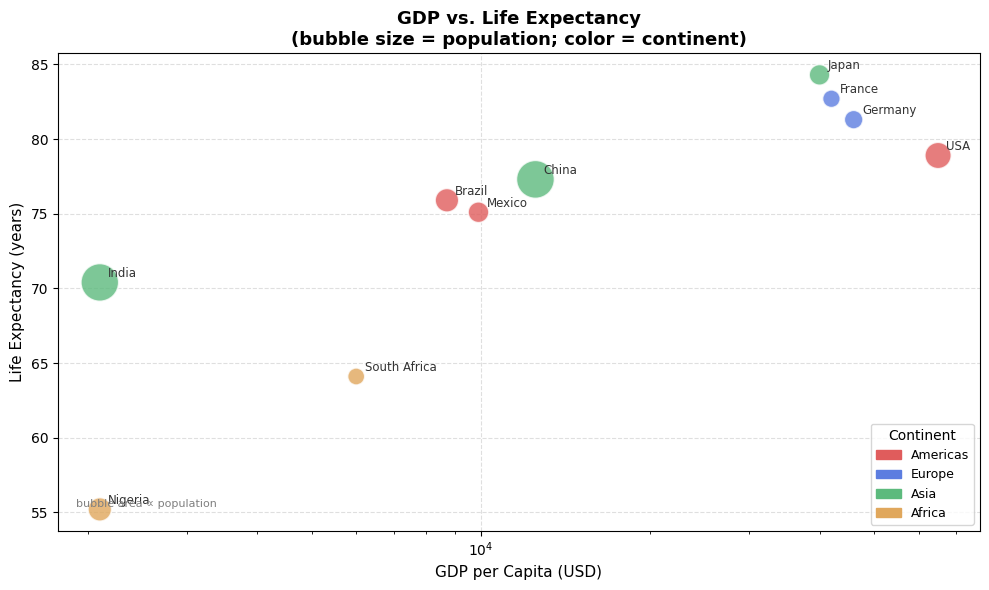

In [6]:
import seaborn as sns

# --- Build a small gapminder-inspired dataset ---
# Attributes: country (categorical), continent (categorical),
#             gdp_per_capita (quantitative), life_expectancy (quantitative),
#             population_millions (quantitative)

country_data = {
    "country":          ["USA", "Germany", "Japan", "Brazil", "India", "Nigeria",
                         "China", "France", "Mexico", "South Africa"],
    "continent":        ["Americas", "Europe", "Asia", "Americas", "Asia", "Africa",
                         "Asia", "Europe", "Americas", "Africa"],
    "gdp_per_capita":   [65000, 46000, 40000, 8700, 2100, 2100,
                         12500, 42000, 9900, 6000],      # USD
    "life_expectancy":  [78.9, 81.3, 84.3, 75.9, 70.4, 55.2,
                         77.3, 82.7, 75.1, 64.1],        # years
    "population_M":     [331, 83, 126, 213, 1380, 211,
                         1412, 67, 128, 59],              # millions
}

df_gap = pd.DataFrame(country_data)

# Continent → color: categorical identity channel
continent_colors = {
    "Americas": "#e05c5c",
    "Europe":   "#5c7de0",
    "Asia":     "#5cba7d",
    "Africa":   "#e0a75c",
}
colors = [continent_colors[c] for c in df_gap["continent"]]

# Population → bubble size: quantitative magnitude channel
# We take sqrt to make area proportional to population (not radius)
sizes = (df_gap["population_M"] ** 0.5) * 20

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_gap["gdp_per_capita"],
    df_gap["life_expectancy"],
    s=sizes,          # area encodes population
    c=colors,         # hue encodes continent
    alpha=0.8,
    edgecolors="white",
    linewidths=1.2,
    zorder=3,
)

# Label each country directly on the chart — avoid a separate legend for points
for _, row in df_gap.iterrows():
    ax.annotate(
        row["country"],
        (row["gdp_per_capita"], row["life_expectancy"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8.5,
        color="#333333",
    )

# Manual legend for continents (identity channel: color hue)
legend_handles = [
    mpatches.Patch(color=color, label=continent)
    for continent, color in continent_colors.items()
]
ax.legend(handles=legend_handles, title="Continent", loc="lower right", fontsize=9)

ax.set_xlabel("GDP per Capita (USD)", fontsize=11)
ax.set_ylabel("Life Expectancy (years)", fontsize=11)
ax.set_title("GDP vs. Life Expectancy\n(bubble size = population; color = continent)",
             fontsize=13, fontweight="bold")
ax.set_xscale("log")   # log scale for GDP — compresses wide range, reveals pattern
ax.grid(True, linestyle="--", alpha=0.4)
ax.annotate("bubble area ∝ population", xy=(0.02, 0.05),
            xycoords="axes fraction", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

## 💡 Interpretation:
Higher GDP strongly correlates with longer life expectancy. Europe and Japan cluster top-right — wealthy and long-lived but small populations. India and China sit mid-left — massive populations with moderate wealth and decent life expectancy. Africa (Nigeria, South Africa) remains bottom-left — low GDP, shortest lives. Wealth buys years, but population size and continent shape how that relationship plays out.

Why bubble chart? This is a bubble chart (scatterplot + size + color) — chosen because it encodes 4 attributes simultaneously:

X-axis (position) → GDP per capita — quantitative, most accurate channel
Y-axis (position) → Life expectancy — quantitative, most accurate channel
Bubble size (area) → Population — quantitative magnitude channel
Color hue → Continent — categorical identity channel

A plain scatterplot would only show 2 attributes. A bar chart couldn't show correlation. A heatmap would lose the population dimension. This idiom is the only one that reveals correlation, magnitude, and group membership all at once — four attributes, one chart.

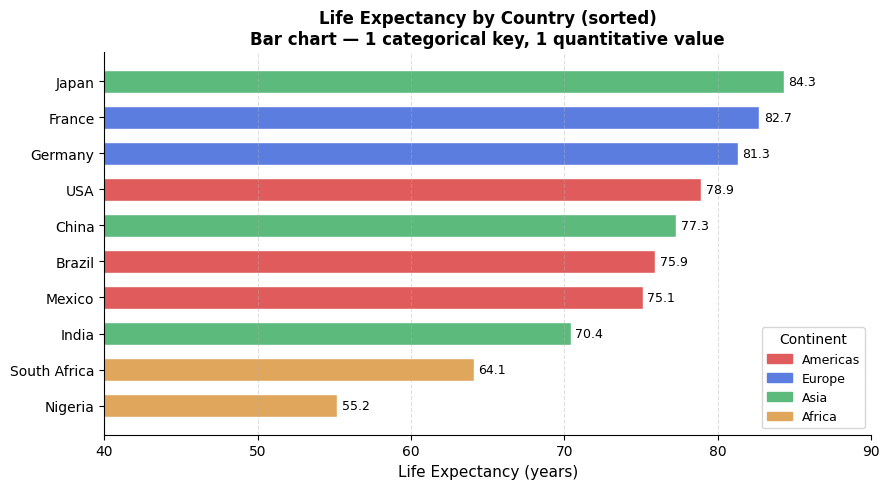

In [7]:
# --- Bar chart: compare life expectancy across countries (1 categorical key, 1 quantitative value) ---
# Task: COMPARE — lookup and compare values across categories
# Design choice: sort bars by value so rank is immediately visible

df_sorted = df_gap.sort_values("life_expectancy", ascending=True)
bar_colors = [continent_colors[c] for c in df_sorted["continent"]]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(df_sorted["country"], df_sorted["life_expectancy"],
               color=bar_colors, edgecolor="white", height=0.65)

# Add value labels to the right of each bar for precise lookup
for bar, val in zip(bars, df_sorted["life_expectancy"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", fontsize=9)

ax.set_xlim(40, 90)
ax.set_xlabel("Life Expectancy (years)", fontsize=11)
ax.set_title("Life Expectancy by Country (sorted)\nBar chart — 1 categorical key, 1 quantitative value",
             fontsize=12, fontweight="bold")

# Continent color legend
legend_handles = [
    mpatches.Patch(color=color, label=cont)
    for cont, color in continent_colors.items()
]
ax.legend(handles=legend_handles, title="Continent", loc="lower right", fontsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 💡 Interpretation:
Japan leads at 84.3 years; Nigeria is lowest at 55.2 — a 29-year gap. Europe and Asia dominate the top. Africa sits at the bottom. Continent is the strongest predictor of life expectancy, with a nearly 30-year spread between best and worst.

Why Bar chart? Bar chart is ideal for comparing one quantity across unordered categories. Sorted bars make rank instant. Color adds continent context. Right idiom, right task — compare values across categories, use bars.

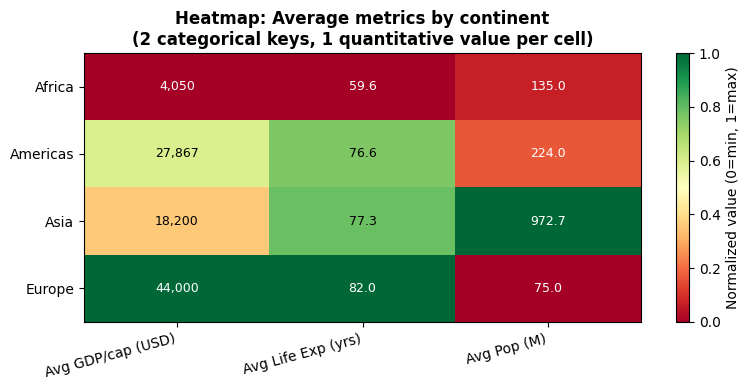

In [8]:
# --- Heatmap: 2 categorical keys, 1 quantitative value ---
# Task: DISCOVER clusters and patterns across a matrix
# Here: average life expectancy and GDP per continent × metric

# Build a summary matrix: continents as rows, metrics as columns
summary = df_gap.groupby("continent")[["gdp_per_capita", "life_expectancy", "population_M"]].mean()
summary.columns = ["Avg GDP/cap (USD)", "Avg Life Exp (yrs)", "Avg Pop (M)"]

# Normalize each column to [0, 1] so different scales don't dominate color
summary_norm = (summary - summary.min()) / (summary.max() - summary.min())

fig, ax = plt.subplots(figsize=(8, 4))

# imshow maps the normalized matrix to a diverging colormap
im = ax.imshow(summary_norm.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

# Axis labels
ax.set_xticks(range(len(summary_norm.columns)))
ax.set_xticklabels(summary_norm.columns, fontsize=10, rotation=15, ha="right")
ax.set_yticks(range(len(summary_norm.index)))
ax.set_yticklabels(summary_norm.index, fontsize=10)

# Annotate each cell with the original (un-normalized) value for context
for i in range(len(summary.index)):
    for j in range(len(summary.columns)):
        raw = summary.iloc[i, j]
        text = f"{raw:,.0f}" if j == 0 else f"{raw:.1f}"
        ax.text(j, i, text, ha="center", va="center", fontsize=9,
                color="black" if 0.3 < summary_norm.iloc[i, j] < 0.85 else "white")

plt.colorbar(im, ax=ax, label="Normalized value (0=min, 1=max)")
ax.set_title("Heatmap: Average metrics by continent\n(2 categorical keys, 1 quantitative value per cell)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 💡 Interpretation:
Europe leads in GDP and life expectancy but has the smallest population. Asia dominates population (972.7M) with mid-range wealth. Africa ranks last on both GDP and life expectancy.

Why heatmap? Two categorical keys (continent × metric) with one quantitative value per cell — exactly the heatmap use case. Color reveals cross-continent patterns at a glance; a table of numbers would require manual scanning to spot the same clusters.

---

# Part 2: Activities

Now it's your turn. Each activity below asks you to apply the concepts from Part 1. Work through them in order — later activities build on earlier ones.

> **Reminder:** Each activity is worth the same number of points.

## 🎯 Activity 1: Datasaurus Dozen — Perception Over Statistics

The **Datasaurus Dozen** is a modern extension of Anscombe's Quartet: 13 datasets that all share the same mean, standard deviation, and correlation (to two decimal places), yet form completely different shapes when visualized.

You are given a subset of three of these datasets below. Your tasks:

1. Print the summary statistics (mean, std, correlation) for each dataset and verify they are nearly identical.
2. Create a `1×3` grid of scatterplots — one panel per dataset — so the shapes become visible(two charts side by side horizontally).
3. In a markdown cell below your plots, write **2–3 sentences** explaining what this example tells us about the role of visualization vs. summary statistics in data analysis.

Dataset: dino
Mean (x): 47.60, Mean (y): 63.10
Std Dev (x): 13.65, Std Dev (y): 24.38
Correlation: 0.1261

Dataset: star
Mean (x): 55.56, Mean (y): 56.47
Std Dev (x): 3.31, Std Dev (y): 26.22
Correlation: 0.8972

Dataset: bullseye
Mean (x): 50.00, Mean (y): 89.40
Std Dev (x): 5.78, Std Dev (y): 2.58
Correlation: -0.4811



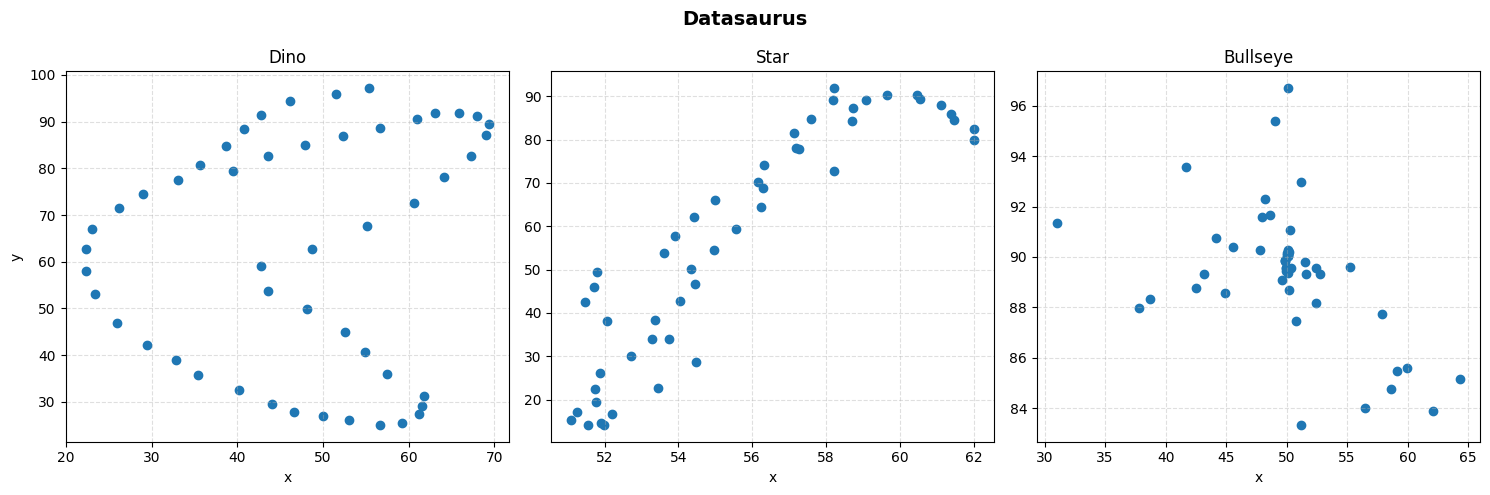

In [9]:
# Data for Activity 1 — three shapes from the Datasaurus Dozen
# All have: x_mean ≈ 54.26, y_mean ≈ 47.83, x_std ≈ 16.77, y_std ≈ 26.94, corr ≈ -0.06

datasaurus = {
    "dino": {
        "x": [55.3846,51.5385,46.1538,42.8205,40.7692,38.7179,35.6410,33.0769,28.9744,26.1538,
              23.0769,22.3077,22.3077,23.3333,25.8974,29.4872,32.8205,35.3846,40.2564,44.1026,
              46.6154,50.0000,53.0769,56.6667,59.2308,61.2821,61.5385,61.7949,57.4359,54.8718,
              52.5641,48.1795,43.5897,42.8205,48.7179,55.1282,60.6410,64.1026,67.3077,69.1026,
              69.3590,67.9487,65.8974,63.0769,61.0256,56.6667,52.3077,47.9487,43.5897,39.4872],
        "y": [97.1795,96.0256,94.4872,91.4103,88.3333,84.8718,80.7692,77.5641,74.4872,71.4103,
              66.9231,62.6923,58.0769,53.0769,46.9231,42.1154,38.9744,35.7692,32.4872,29.4872,
              27.7564,26.9872,26.0256,25.0641,25.5128,27.3333,29.1026,31.2564,36.0256,40.6410,
              45.0000,49.8718,53.7564,59.1026,62.6923,67.5641,72.5641,78.0769,82.6923,87.1795,
              89.4872,91.2564,91.8718,91.7564,90.5128,88.7436,86.9744,85.0256,82.6923,79.4872],
    },
    "star": {
        "x": [58.2136,58.1961,58.7084,57.1962,58.2136,56.2802,56.2274,55.5732,54.9582,54.3396,
              54.4527,54.0434,53.3624,53.2974,52.7186,51.8714,51.7546,51.7826,51.2623,51.1037,
              51.5552,51.9928,51.9109,52.2066,53.4399,54.4699,53.7587,52.0758,51.4724,51.7246,
              51.8023,53.6167,53.9116,54.4130,55.0019,56.1670,56.3099,57.2719,57.1439,57.5894,
              58.7286,59.0701,59.6490,60.4702,60.5453,61.1027,61.3721,61.4732,62.0033,62.0115],
        "y": [91.8819,89.0888,84.4163,78.0827,72.8548,68.7827,64.4798,59.4745,54.5459,50.1581,
              46.7971,42.8523,38.3091,33.9684,30.0321,26.1416,22.5290,19.5451,17.1488,15.3566,
              14.1735,14.2380,14.5695,16.6862,22.7573,28.6699,34.0499,38.1484,42.4741,46.1028,
              49.5567,53.7399,57.8793,62.1456,66.0218,70.2716,74.0680,77.8900,81.4434,84.7048,
              87.2753,89.0651,90.3648,90.2951,89.4498,87.9238,86.0000,84.5631,82.4337,80.0000],
    },
    "bullseye": {
        "x": [51.2096,59.0898,41.6638,50.0986,50.1247,31.0327,64.3073,51.1997,45.5966,62.0750,
              38.7282,49.0791,57.8400,44.9124,59.9799,37.7717,42.5240,58.5972,43.1471,56.4620,
              48.6399,55.2700,44.1386,48.2056,52.4168,50.8014,51.4847,52.7519,50.3110,50.0786,
              47.9975,51.6230,47.8131,52.4048,49.8784,50.2090,50.0645,49.6063,50.3842,50.2043,
              49.9714,50.1111,49.8860,50.1231,49.9540,50.0476,49.9714,50.1111,49.8860,50.1231],
        "y": [83.3377,85.4695,93.5657,90.2895,96.6978,91.3612,85.1443,92.9630,90.3820,83.8895,
              88.3445,95.3875,87.7360,88.5832,85.5760,87.9625,88.7519,84.7720,89.3190,84.0150,
              91.6560,89.6125,90.7360,92.3050,88.1930,87.4410,89.7870,89.3280,91.0780,89.3830,
              91.5810,89.3050,90.2890,89.5780,89.8950,88.6840,90.1540,89.0670,89.5430,90.2130,
              89.5780,90.1230,89.8430,90.0560,89.4320,90.0890,89.5780,90.1230,89.8430,90.0560],
    },
}

# ── Your solution goes here ──

# 1. Print the summary statistics (mean, std, correlation) for each dataset and 
# verify they are nearly identical.
for name, data in datasaurus.items():
    x, y = np.array(data["x"]), np.array(data["y"])
    mean_x, mean_y = np.mean(x), np.mean(y)
    std_x, std_y = np.std(x), np.std(y)
    corr = np.corrcoef(x, y)[0, 1]
    print(f"Dataset: {name}")
    print(f"Mean (x): {mean_x:.2f}, Mean (y): {mean_y:.2f}")
    print(f"Std Dev (x): {std_x:.2f}, Std Dev (y): {std_y:.2f}")
    print(f"Correlation: {corr:.4f}\n")

# 2. Create a `1×3` grid of scatterplots — one panel per dataset — so the shapes 
# become visible(two charts side by side horizontally).
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (name, data) in enumerate(datasaurus.items()):
      x = np.array(data["x"])
      y = np.array(data["y"])

      axes[i].scatter(x, y)
      axes[i].set_title(name.capitalize())
      
      axes[i].set_xlabel("x")
      if i == 0:
            axes[i].set_ylabel("y")
      axes[i].grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Datasaurus", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 3. In a markdown cell below your plots, write **2–3 sentences** explaining what 
# this example tells us about the role of visualization vs. summary statistics in data analysis.

**Written reflection:**

Los datasets tienen estadísticas bastante similares entre sí, aunque algunas sí varían como por ejemplo las relacionadas a dispersión de los datos. Sin embargo, vemos que sus gráficos son totalmente distintos y forman estructuras que no son similares. Esto nos demuestra que las estadísticas pueden esconder ciertos patrones importantes que solo son expuestos al momento de visualizar la data, tales como formas, clusters y datos atípicos.

## 🎯 Activity 2: Spot and Fix a Misleading Visualization

Below is a dataset showing the monthly average temperature (°C) recorded in Quito during 2024. A colleague has produced two bar charts from this data — one of which is misleading.

Your tasks:

1. Run the provided code to see both charts.
2. In a markdown cell, identify **which chart is misleading, why it is misleading, and what specific technique from the lecture it uses**.
3. Write code that produces a **third, corrected version** of the misleading chart that accurately represents the data.

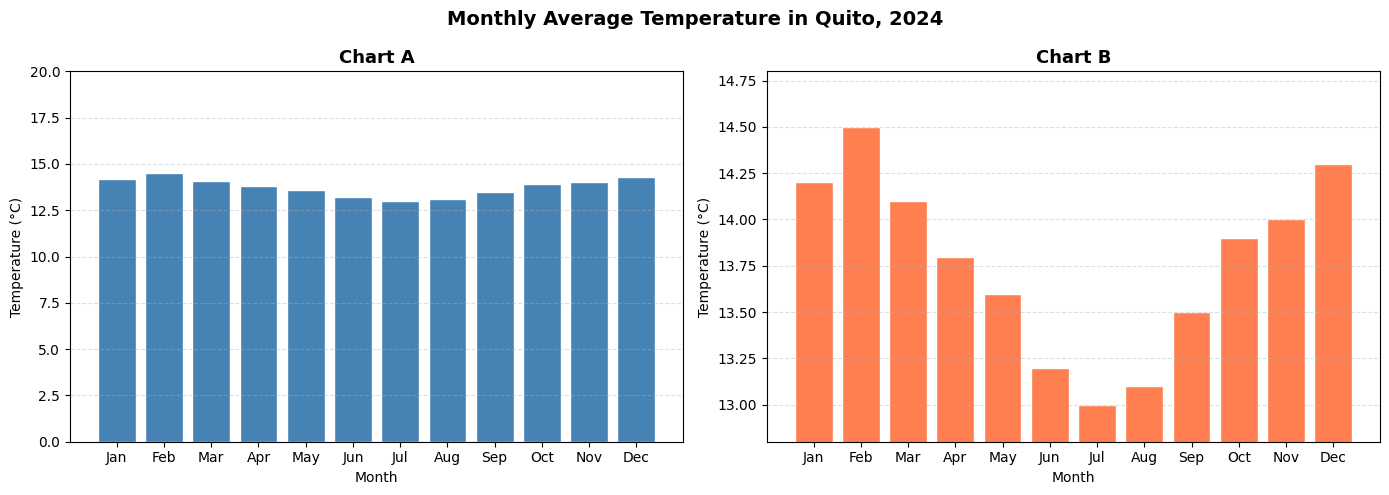

In [10]:
# Monthly average temperature in Quito, 2024 (°C)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
temps  = [14.2, 14.5, 14.1, 13.8, 13.6, 13.2,
          13.0, 13.1, 13.5, 13.9, 14.0, 14.3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Chart A
ax1.bar(months, temps, color="steelblue", edgecolor="white")
ax1.set_ylim(0, 20)
ax1.set_title("Chart A", fontsize=13, fontweight="bold")
ax1.set_ylabel("Temperature (°C)")
ax1.set_xlabel("Month")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Chart B
ax2.bar(months, temps, color="coral", edgecolor="white")
ax2.set_ylim(12.8, 14.8)
ax2.set_title("Chart B", fontsize=13, fontweight="bold")
ax2.set_ylabel("Temperature (°C)")
ax2.set_xlabel("Month")
ax2.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Monthly Average Temperature in Quito, 2024", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Identify which is misleading and write your corrected chart below ──

**Your analysis here (replace this text):**

*Which chart is misleading? What technique does it use? Why is it deceptive?*

Chart B is misleading because the y-axis does not start at zero. It is using a truncated (non-zero) y axis. In bar charts, the length of each bar represents the value, so the axis should begin at 0. It is deceptive because by truncating the y axis, the differences between the bars appear much larger than they actually are. This exaggerates the variation in the data and can lead viewers to draw incorrect conclusions.

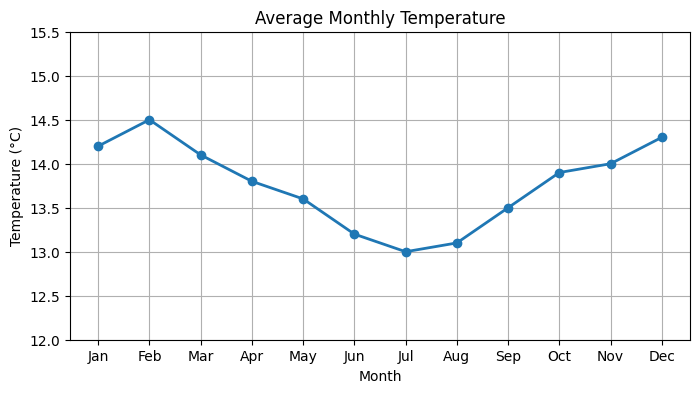

In [11]:
y_min = min(temps) - 1
y_max = max(temps) + 1

plt.figure(figsize=(8, 4))
plt.plot(months, temps, marker='o', linewidth=2)

plt.title("Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.ylim(y_min, y_max)
plt.grid(True)

plt.show()

## 🎯 Activity 3: Data Abstraction — Classify a New Dataset

Below is a dataset about streaming music tracks. Before you can visualize it, you need to understand what kind of data you have.

Your tasks:

1. Load the dataset into a `DataFrame` and display it.
2. For **each column**, write its attribute type (categorical, ordinal, or quantitative) and briefly justify your choice (one sentence per column is enough).
3. State the **dataset type** (table, network, field, or geometry) and explain why.
4. For each of the following analytical questions, identify the **{action, target} pair** from Munzner's vocabulary and suggest the most appropriate chart idiom:
   - "Which genre has the highest average stream count?"
   - "Is there a relationship between track duration and stream count?"
   - "How does a single track's popularity rank compare between this year and last year?"

In [12]:
# Dataset for Activity 3
tracks = {
    "track_id":       [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "title":          ["Neon Lights", "Desert Road", "Pulse", "Blue Echo", "Free Fall",
                       "Midnight Run", "Orbit", "Coastal", "Drift", "Storm Warning"],
    "artist":         ["Nova", "Rojo", "Nova", "Echo", "Rojo",
                       "Echo", "Nova", "Coast", "Coast", "Rojo"],
    "genre":          ["Pop", "Rock", "Electronic", "Pop", "Rock",
                       "Electronic", "Electronic", "Pop", "Rock", "Rock"],
    "explicit":       [False, True, False, False, True,
                       False, True, False, False, True],
    "duration_sec":   [210, 245, 190, 225, 260, 195, 230, 215, 250, 240],
    "streams_M":      [45.2, 31.8, 62.1, 28.5, 19.3, 53.7, 40.0, 35.6, 22.4, 15.1],
    "chart_rank_now": [3, 8, 1, 12, 18, 2, 5, 9, 15, 22],
    "chart_rank_prev":[7, 6, 2, 10, 20, 4, 8, 11, 14, 17],
    "popularity":     ["High", "Medium", "High", "Medium", "Low",
                       "High", "High", "Medium", "Low", "Low"],
}

df_tracks = pd.DataFrame(tracks)
print(df_tracks.to_string(index=False))

# ── Write your attribute type classifications and task analysis below ──

 track_id         title artist      genre  explicit  duration_sec  streams_M  chart_rank_now  chart_rank_prev popularity
        1   Neon Lights   Nova        Pop     False           210       45.2               3                7       High
        2   Desert Road   Rojo       Rock      True           245       31.8               8                6     Medium
        3         Pulse   Nova Electronic     False           190       62.1               1                2       High
        4     Blue Echo   Echo        Pop     False           225       28.5              12               10     Medium
        5     Free Fall   Rojo       Rock      True           260       19.3              18               20        Low
        6  Midnight Run   Echo Electronic     False           195       53.7               2                4       High
        7         Orbit   Nova Electronic      True           230       40.0               5                8       High
        8       Coastal  Coast  

**Your classifications here (replace this text):**

| Column | Type | Justification |
|---|---|---|
| track_id | ? | ? |
| title | ? | ? |
| artist | ? | ? |
| genre | ? | ? |
| explicit | ? | ? |
| duration_sec | ? | ? |
| streams_M | ? | ? |
| chart_rank_now | ? | ? |
| chart_rank_prev | ? | ? |
| popularity | ? | ? |

**Dataset type:** ?

**Task analysis:**

| Question | Action | Target | Idiom |
|---|---|---|---|
| Which genre has the highest avg streams? | ? | ? | ? |
| Relationship between duration and streams? | ? | ? | ? |
| How does a track's rank compare year-over-year? | ? | ? | ? |

## 🎯 Activity 4: Marks, Channels, and Expressiveness

The tracks dataset from Activity 3 is reused here. You will design and implement a bubble chart that encodes **four attributes simultaneously** using different visual channels.

Your tasks:

1. Create a scatterplot using the `df_tracks` dataset with:
   - **x-axis**: `duration_sec` (quantitative)
   - **y-axis**: `streams_M` (quantitative)
   - **Bubble size**: proportional to `chart_rank_now` — but inverted (rank 1 = largest bubble, rank 22 = smallest) so that higher-ranked tracks are visually prominent. Make sure area, not radius, is proportional to the value.
   - **Color hue**: encode `genre` (categorical) using a distinct color per genre.
   - **Label**: annotate each point with the track title.

2. In a markdown cell, answer the following:
   - For each of the four channels you used (x-position, y-position, size, color), state whether it is a **magnitude channel** or an **identity channel**, and explain whether the choice follows the **expressiveness principle**.
   - Is there any channel combination in your chart that suffers from **separability issues**(that is, when two channels interfere with each other and are difficult to read separately)? Why or why not?

In [13]:
# ── Your solution goes here ──
# df_tracks is already defined from Activity 3 — just use it directly

**Your channel analysis here (replace this text):**

| Channel | Attribute encoded | Magnitude or Identity? | Expressiveness principle satisfied? |
|---|---|---|---|
| x-position | duration_sec | ? | ? |
| y-position | streams_M | ? | ? |
| size (area) | chart_rank_now (inverted) | ? | ? |
| color hue | genre | ? | ? |

**Separability analysis:** *(your answer here)*

## 🎯 Activity 5: Choose the Right Idiom and Justify It

For each of the five scenarios below, you will:

1. **Identify the dataset and attribute types** involved.
2. **Choose the most appropriate chart idiom** from what was covered in the lecture (bar chart, line chart, scatterplot, heatmap, stacked bar, slopegraph, pie chart — or a justified alternative).
3. **Implement the chart** in Python using matplotlib/seaborn.
4. **In a markdown cell, write a one-sentence justification** for your idiom choice as a code comment.

**Scenarios** (use the data provided in the code cell below):

- **5A**: Show how average monthly website visitors changed over 12 months (trend over time).
- **5B**: Show the composition of revenue(income) by product category for a single quarter (part-to-whole).
- **5C**: Compare the average score of students across 5 departments (comparison across categories).
- **5D**: Use a heatmap to show the average score for each combination of department and study method.
- **5E**: Show whether hours studied and exam score are correlated across individual students.

In [14]:
# --- Data for Activity 5 ---

# 5A: Monthly web visitors (ordered key: month; quantitative value: visitors)
months_web = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
visitors_K = [120, 135, 118, 142, 160, 175, 188, 195, 170, 155, 140, 165]

# 5B: Revenue by category for Q3 (categorical key; quantitative value: proportion)
categories_rev = ["Software", "Hardware", "Services", "Subscriptions", "Other"]
revenue_pct    = [34, 22, 18, 20, 6]   # percentages summing to 100

# 5C: Average exam score by department (categorical key; quantitative value: avg score)
departments   = ["Engineering", "Business", "Arts", "Sciences", "Medicine"]
avg_scores    = [78.4, 81.2, 74.6, 83.1, 85.7]

# 5D: Average score by department × study method (2 categorical keys; 1 quantitative value)
study_methods = ["Solo", "Group", "Online"]
score_matrix  = {
    "Engineering": [76, 80, 79],
    "Business":    [82, 85, 78],
    "Arts":        [73, 77, 72],
    "Sciences":    [84, 81, 85],
    "Medicine":    [87, 83, 86],
}
df_matrix = pd.DataFrame(score_matrix, index=study_methods)

# 5E: Individual students — hours studied vs exam score (2 quantitative attributes)
np.random.seed(42)
n_students = 40
hours  = np.random.uniform(2, 20, n_students)
scores = 50 + 2.1 * hours + np.random.normal(0, 5, n_students)   # linear trend + noise

# ── Your charts for 5A through 5E go here ──

**Your written reflection here (replace this text):**

In a markdown cell, write a one-sentence justification for your idiom choice as a code comment